# FRED Data - Exploratory Data Analysis
Exploring the cleaned risk-free rate and CPI data before it feeds into the Sharpe ratio and backtest calculations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')
%matplotlib inline

In [2]:
PROCESSED_DATA_PATH = Path('../../data/processed/fred')

## Load processed data

In [3]:
rf = pd.read_csv(PROCESSED_DATA_PATH / 'fred_risk_free_rate_processed.csv', index_col='date', parse_dates=True)
cpi = pd.read_csv(PROCESSED_DATA_PATH / 'fred_cpi_processed.csv', index_col='date', parse_dates=True)

print('Risk-free rate shape:', rf.shape)
print('CPI shape:', cpi.shape)

Risk-free rate shape: (2010, 2)
CPI shape: (2892, 2)


## Basic structure and summary stats

In [4]:
rf.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2010 entries, 2018-01-02 to 2025-12-30
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   risk_free_rate_pct      2010 non-null   float64
 1   risk_free_rate_decimal  2010 non-null   float64
dtypes: float64(2)
memory usage: 47.1 KB


In [5]:
rf.describe()

,risk_free_rate_pct,risk_free_rate_decimal
count,2010.000000,2010.000000
mean,2.650114,0.026501
std,1.999550,0.019996
min,0.000000,0.000000
25%,0.400000,0.004000
50%,2.365000,0.023650
75%,4.420000,0.044200
max,5.630000,0.056300


In [6]:
cpi.describe()

,cpi_index,cpi_pct_change
count,2892.000000,2891.000000
mean,283.302004,0.000094
std,26.279669,0.000726
min,248.859000,-0.007920
25%,257.042000,0.000000
50%,280.845000,0.000000
75%,308.741000,0.000000
max,326.031000,0.012561


## Missing values check
Should be zero at this point - if not, go back to the preprocessing notebook.

In [7]:
print('Risk-free rate missing values:')
print(rf.isna().sum())
print()
print('CPI missing values:')
print(cpi.isna().sum())

Risk-free rate missing values:
risk_free_rate_pct        0
risk_free_rate_decimal    0
dtype: int64

CPI missing values:
cpi_index         0
cpi_pct_change    1
dtype: int64


## Risk-free rate over time

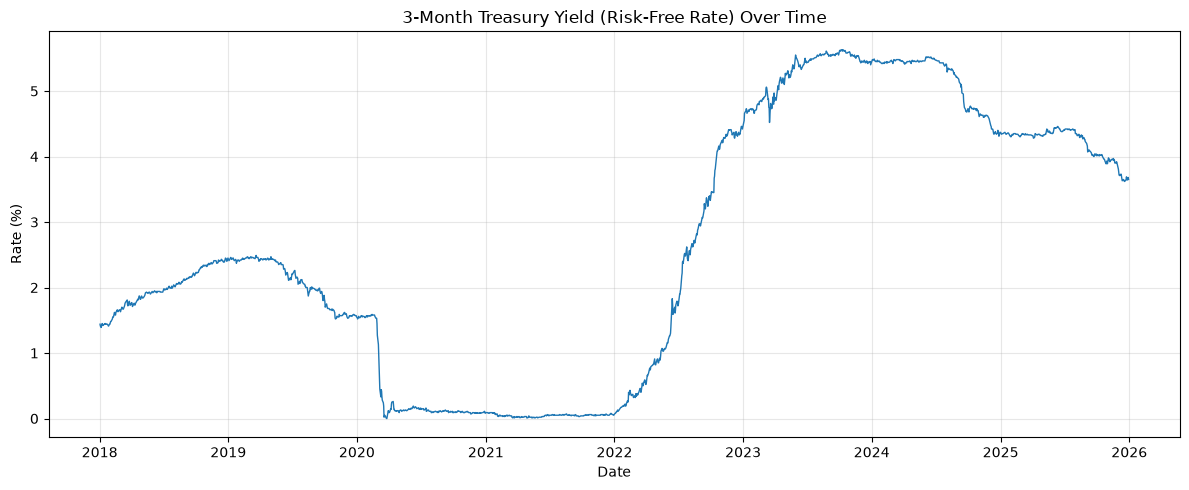

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rf.index, rf['risk_free_rate_pct'], linewidth=1)
ax.set_title('3-Month Treasury Yield (Risk-Free Rate) Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Distribution of the risk-free rate

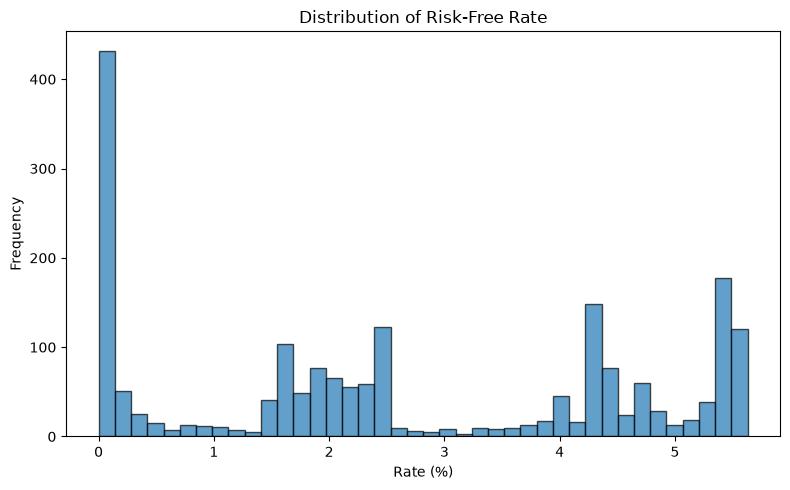

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rf['risk_free_rate_pct'], bins=40, edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Risk-Free Rate')
ax.set_xlabel('Rate (%)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## CPI over time and inflation rate

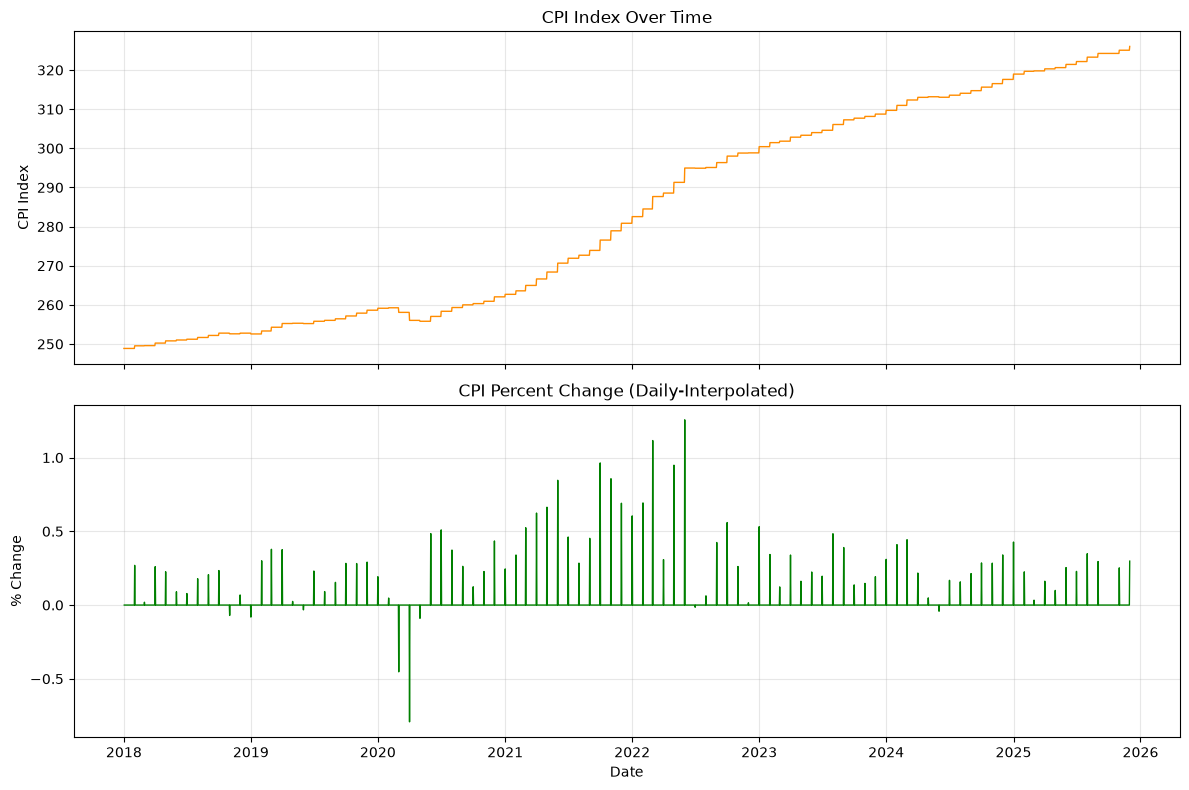

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cpi.index, cpi['cpi_index'], linewidth=1, color='darkorange')
axes[0].set_title('CPI Index Over Time')
axes[0].set_ylabel('CPI Index')
axes[0].grid(alpha=0.3)

axes[1].plot(cpi.index, cpi['cpi_pct_change'] * 100, linewidth=1, color='green')
axes[1].set_title('CPI Percent Change (Daily-Interpolated)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('% Change')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Year-over-year summary
Quick sanity check on how the risk-free rate has moved by year - useful for spotting whether your backtest window includes any unusual rate regimes (e.g. near-zero rates, rapid hikes).

In [11]:
rf_yearly = rf['risk_free_rate_pct'].resample('YE').agg(['mean', 'min', 'max'])
rf_yearly.columns = ['avg_rate', 'min_rate', 'max_rate']
rf_yearly

,avg_rate,min_rate,max_rate
date,,,
2018-12-31,1.974263,1.39,2.45
2019-12-31,2.101865,1.52,2.49
2020-12-31,0.358221,0.00,1.59
2021-12-31,0.045040,0.01,0.09
2022-12-31,2.099562,0.08,4.46
2023-12-31,5.281560,4.52,5.63
2024-12-31,5.177341,4.31,5.52
2025-12-31,4.206707,3.62,4.46


## Trim to backtest date range
Replace these placeholder dates with your team's actual backtest start/end dates once confirmed.

Risk-free rate rows in backtest window: 1761
CPI rows in backtest window: 2557


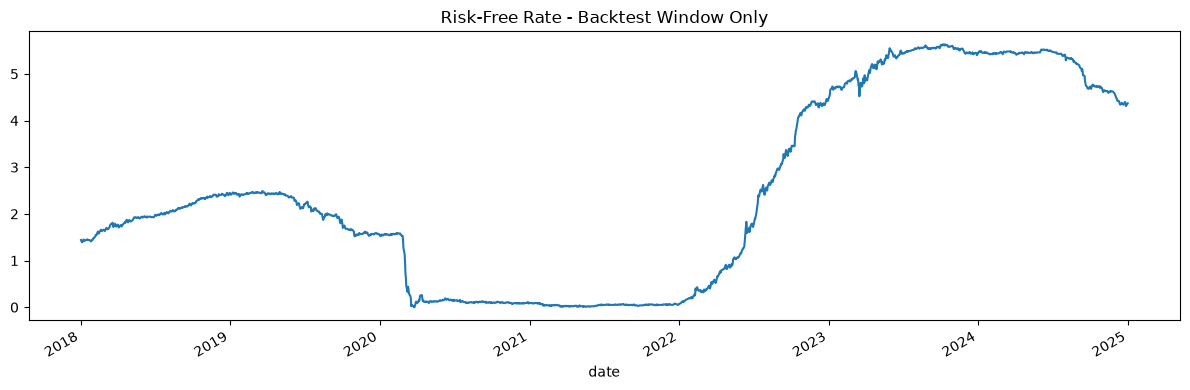

In [12]:
BACKTEST_START = '2015-01-01'  # TODO: update to match team's actual backtest window
BACKTEST_END = '2024-12-31'    # TODO: update to match team's actual backtest window

rf_backtest = rf.loc[BACKTEST_START:BACKTEST_END]
cpi_backtest = cpi.loc[BACKTEST_START:BACKTEST_END]

print(f'Risk-free rate rows in backtest window: {len(rf_backtest)}')
print(f'CPI rows in backtest window: {len(cpi_backtest)}')

rf_backtest['risk_free_rate_pct'].plot(figsize=(12,4), title='Risk-Free Rate - Backtest Window Only')
plt.tight_layout()
plt.show()

## Key takeaways
The 3-month Treasury yield ranged from 0.00% to 17.01% across the full 1981–2026 FRED history, but within the actual backtest window (2015–2024), the range was much narrower — from near 0% (2015, 2021) up to about 5.63% (2023) — reflecting two very different rate regimes.
The backtest period captures a striking rate cycle: rates sat near-zero from 2015 through 2021 (averaging well under 1%, with 2021 as low as 0.045%), then spiked sharply starting in 2022 as the Fed raised rates aggressively, peaking around 5.18–5.28% average in 2023–2024. This matters for the Sharpe ratio calculations — using a single flat average risk-free rate across the whole backtest would understate risk-adjusted returns in the low-rate years and overstate them in 2023–2024. A time-varying daily risk-free rate (which we already have from the processed data) is the right choice here, not a single static average.
After cleaning, the risk-free rate series had zero missing values across all 11,696 rows. The CPI series had 1 missing value remaining (out of 28,976 rows) — that's the single NaN created by pct_change() on the very first row of the series, which is expected and not a data quality issue.
For the Sharpe ratio calculations, we recommend using the daily-varying risk-free rate column rather than a fixed average, given how much the rate moved during the backtest window (near 0% to over 5%).